<a href="https://colab.research.google.com/github/9terry-student/PyTorch/blob/main/%EC%88%9C%ED%99%98_%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 22장 시퀀스 배열로 다루는 순환 신경망

## 1. LSTM을 이용한 로이터 뉴스 카테고리 분류하기

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.datasets import reuters     # 로이터 뉴스 데이터셋 호출
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터 호출 및 학습셋, 테스트셋으로 나눔
(X_train,y_train),(X_test,y_test)=reuters.load_data(num_words=1000,test_split=0.2)

# 데이터 확인
category=np.max(y_train)+1
print(category,'카테고리')
print(len(X_train),'학습용 뉴스 기사')
print(len(X_test),'테스트용 뉴스 기사')
print(X_train[0])

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [2]:
# 단어의 수 맞춤
X_train=sequence.pad_sequences(X_train,maxlen=100)
X_test=sequence.pad_sequences(X_test,maxlen=100)

# 원-핫 인코딩 처리
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# 모델 구조 설정
model=Sequential()
model.add(Embedding(1000,100))
model.add(LSTM(100,activation='tanh'))
model.add(Dense(46,activation='softmax'))

# 모델 실행 옵션 설정
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# 학습 조기 중단 설정
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=5)

# 모델 실행
history=model.fit(X_train,y_train,batch_size=20,epochs=200,validation_data=(X_test,y_test),
                  callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print('\n Test Accuracy: %.4f'%(model.evaluate(X_test,y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4440 - loss: 2.1927 - val_accuracy: 0.5419 - val_loss: 1.8757
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5523 - loss: 1.7367 - val_accuracy: 0.5815 - val_loss: 1.6743
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6068 - loss: 1.5629 - val_accuracy: 0.6278 - val_loss: 1.4988
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6494 - loss: 1.3651 - val_accuracy: 0.6492 - val_loss: 1.3750
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6792 - loss: 1.2445 - val_accuracy: 0.6679 - val_loss: 1.2951
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7126 - loss: 1.1322 - val_accuracy: 0.6861 - val_loss: 1.2313
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7397 - loss: 1.0257 - val_accuracy: 0.6928 - val_loss: 1.1813
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7612 - loss: 0.9504 - val

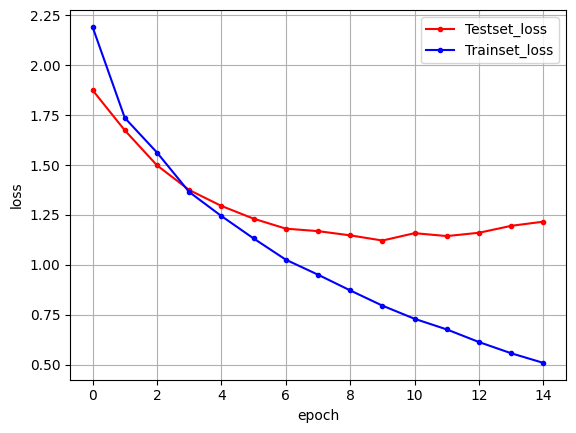

In [3]:
# 학습셋과 테스트셋의 오차 저장
y_vloss=history.history['val_loss']
y_loss=history.history['loss']

# 그래프 표현
x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

# 그래프에 그리드 및 레이블 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 2. LSTM과 CNN의 조합을 이용한 영화 리뷰 분류하기

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Embedding,LSTM,Conv1D,MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터 호출 및 학습셋, 테스트셋으로 나눔
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_wrods=5000)

# 단어의 수 맞춤
X_train=sequence.pad_sequences(X_train,maxlen=500)
X_test=sequence.pad_sequences(X_test,maxlen=500)

# 모델 구조 설정
model=Sequential()
model.add(Embedding(5000,100))
model.build((None,500))
model.add(Dropout(0.5))
model.add(Conv1D(64,5,padding='valid',activation='relu',strides=1))
model.add(MaxPooling1D(pool_size=4))
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 496, 64)        │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 모델 실행 옵션 설정
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# 학습 조기중단 설정
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=3)

# 모델 실행
history=model.fit(X_train,y_train,batch_size=40,epochs=100,validation_split=0.25,
                  callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print('\n Test Accuracy: %.4f'%(model.evaluate(X_test,y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8085 - loss: 0.3925 - val_accuracy: 0.8779 - val_loss: 0.3012
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9078 - loss: 0.2352 - val_accuracy: 0.8915 - val_loss: 0.2667
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9292 - loss: 0.1857 - val_accuracy: 0.8934 - val_loss: 0.2690
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9478 - loss: 0.1421 - val_accuracy: 0.8904 - val_loss: 0.2952
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9572 - loss: 0.1194 - val_accuracy: 0.8862 - val_loss: 0.3164
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8747 - loss: 0.3480

 Test Accuracy: 0.8747


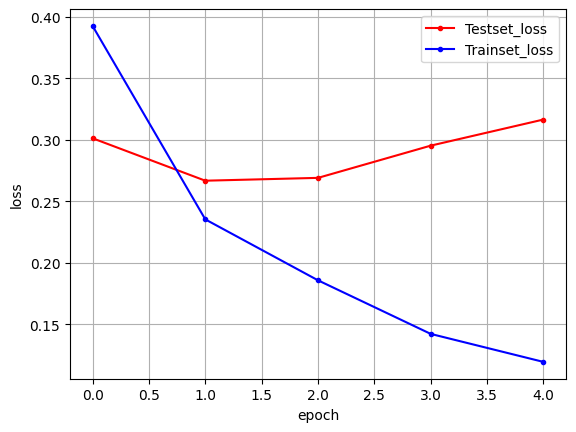

In [6]:
# 학습셋과 테스트셋의 오차 저장
y_vloss=history.history['val_loss']
y_loss=history.history['loss']

# 그래프 표현
x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

# 그래프에 그리드 및 레이블 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 3. seq2seq 모델과 어텐션

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 4.1121 - val_accuracy: 0.0000e+00 - val_loss: 4.1035
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 4.0970 - val_accuracy: 0.0000e+00 - val_loss: 4.0942
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 4.0816 - val_accuracy: 0.0000e+00 - val_loss: 4.0844
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6250 - loss: 4.0651 - val_accuracy: 0.2500 - val_loss: 4.0734
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6250 - loss: 4.0467 - val_accuracy: 0.2500 - val_loss: 4.0608
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6250 - loss: 4.0253 - val_accuracy: 0.2500 - val_loss: 4.0460
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6250 - loss: 4.0000 - val_accuracy: 0.2500 - val_loss: 4.0283
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6250 - loss: 3.9695 - val_accuracy: 0.2500 

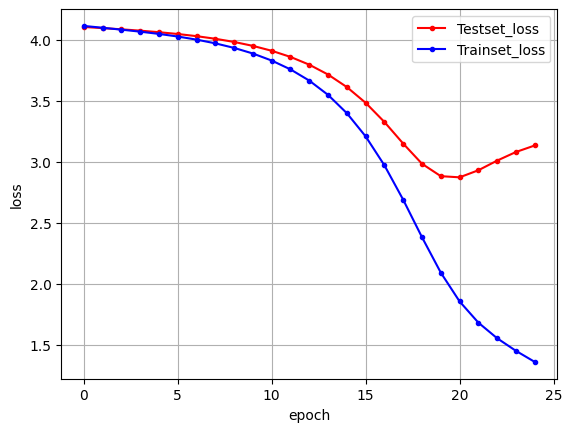

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,LSTM,Dense,Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# 예제용 데이터셋
# 한국어 입력 (X_data)
# '오늘 날씨 어때' -> [1,2,3]
# '오늘 주가 얼마' -> [1,4,5]
# '날씨가 점점 따뜻해' -> [6,7,8]
X_data=[
    [1,2,3],
    [1,4,5],
    [6,7,8]
]

# 영어 출력 (Y-data)
# 'It is warm' -> [10,20,30]
# 'It is high' -> [10,20,50]
# 'Getting warm' -> [60,30]
Y_data=[
    [10,20,30],
    [10,20,50],
    [60,30]
]

# 패딩
X_train=pad_sequences(X_data,maxlen=5)      # 입력 시퀀스 길이 5로 맞춤
Y_train=pad_sequences(Y_data,maxlen=4)      # 출력 시퀀스 길이 4로 맞춤

# 입력 단어 집합 크기와 출력 단어 집합 크기 자동 설정
input_vocab_size=np.max(X_train)+1
output_vocab_size=np.max(Y_train)+1

# 원-핫 인코딩 (출력 데이터용)
y_train=to_categorical(Y_train,num_classes=output_vocab_size)

# 인코더 정의
encoder_inputs=Input(shape=(5,))
enc_emb=Embedding(input_dim=input_vocab_size,output_dim=64)(encoder_inputs)
encoder_lstm=LSTM(128,return_state=True)
encoder_outputs,state_h,state_c=encoder_lstm(enc_emb)

# 디코더 정의
decoder_inputs=Input(shape=(4,))
dec_emb=Embedding(input_dim=output_vocab_size,output_dim=64)(decoder_inputs)
decoder_lstm=LSTM(128,return_sequences=True,return_state=True)
decoder_outputs,_,_=decoder_lstm(dec_emb,initial_state=[state_h,state_c])
decoder_dense=Dense(int(output_vocab_size),activation='softmax')
decoder_outputs=decoder_dense(decoder_outputs)

# 모델 구성
model=Model([encoder_inputs,decoder_inputs],decoder_outputs)

# 모델 컴파일
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# 모델 학습
history=model.fit([X_train,Y_train],y_train,batch_size=2,epochs=25,validation_split=0.2)

# 학습 과정 시각화
y_vloss=history.history['val_loss']
y_loss=history.history['loss']
x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()